# Notebook 4 — T-Closeness
Uses **Total Variation Distance (TVD)** for categorical `fitness_level`.
No numeric EMD — `heart_rate`/`calories` are not sensitive.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json, os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('../data', exist_ok=True)
os.makedirs('../results', exist_ok=True)

df          = pd.read_csv('../data/l_diverse.csv')
df_original = pd.read_csv('../data/raw_fitness_data.csv')

assert 'fitness_level' in df.columns, 'Run Notebooks 1-3 first.'

quasi_identifiers   = ['age', 'region', 'activity']
sensitive_attribute = 'fitness_level'
fitness_classes     = ['fit', 'moderately_fit', 'unfit']

print(f'✅ L-diverse dataset loaded — shape: {df.shape}')
print('\nfitness_level distribution:')
print(df['fitness_level'].value_counts())

✅ L-diverse dataset loaded — shape: (7000, 11)

fitness_level distribution:
fitness_level
moderately_fit    3973
fit               1520
unfit             1507
Name: count, dtype: int64


In [2]:
# Population reference distribution for fitness_level
pop_fl_dist = df_original['fitness_level'].value_counts(normalize=True)
pop_fl_dist = pop_fl_dist.reindex(fitness_classes, fill_value=0)

print('Population fitness_level distribution (reference):')
print(pop_fl_dist.round(4))


# TVD for categorical attributes
def tvd(p, q):
    """Total Variation Distance for categorical distributions."""
    keys = q.index
    p_aligned = p.reindex(keys, fill_value=0)
    return 0.5 * sum(abs(p_aligned[i] - q[i]) for i in keys)

print('\n✅ TVD function defined')

Population fitness_level distribution (reference):
fitness_level
fit               0.2104
moderately_fit    0.5770
unfit             0.2126
Name: proportion, dtype: float64

✅ TVD function defined


In [3]:
t_threshold = 0.25
t_results   = []
violations_before = 0

for group_key, group_data in df.groupby(quasi_identifiers):
    group_dist = group_data['fitness_level'].value_counts(normalize=True)
    group_dist = group_dist.reindex(fitness_classes, fill_value=0)
    distance   = tvd(group_dist, pop_fl_dist)

    t_results.append({'group': group_key, 'tvd': distance, 'violates': distance > t_threshold, 'size': len(group_data)})
    if distance > t_threshold:
        violations_before += 1

t_df = pd.DataFrame(t_results)

print(f'T-CLOSENESS BEFORE MITIGATION (t={t_threshold}, metric: TVD):')
print(f'  Total groups:     {len(t_df)}')
print(f'  Violating groups: {violations_before}')
print(f'  Violation rate:   {100*violations_before/len(t_df):.1f}%')
print(f'\nTVD statistics:')
print(t_df['tvd'].describe())

T-CLOSENESS BEFORE MITIGATION (t=0.25, metric: TVD):
  Total groups:     143
  Violating groups: 57
  Violation rate:   39.9%

TVD statistics:
count    143.000000
mean       0.282924
std        0.172236
min        0.052630
25%        0.162429
50%        0.196585
75%        0.417861
max        0.787429
Name: tvd, dtype: float64


In [4]:
# ---------------------------------------------------------------
# T-Closeness Mitigation (categorical, deterministic)
# For violating groups:
#   - find over-represented and under-represented fitness_level class
#   - reassign boundary record (by steps) from over -> under class
# ---------------------------------------------------------------
df_t = df.copy()
corrections = 0

for group_key, group_data in df_t.groupby(quasi_identifiers):
    if len(group_data) < 3:
        continue

    group_dist = group_data['fitness_level'].value_counts(normalize=True)
    group_dist = group_dist.reindex(fitness_classes, fill_value=0)
    distance   = tvd(group_dist, pop_fl_dist)

    if distance <= t_threshold:
        continue

    diff        = group_dist - pop_fl_dist
    over_class  = diff.idxmax()
    under_class = diff.idxmin()

    over_records = group_data[group_data['fitness_level'] == over_class]
    if len(over_records) < 2:
        continue

    if under_class == 'fit':
        target_idx = over_records['steps'].idxmax()
    elif under_class == 'unfit':
        target_idx = over_records['steps'].idxmin()
    else:
        med = over_records['steps'].median()
        target_idx = (over_records['steps'] - med).abs().idxmin()

    df_t.loc[target_idx, 'fitness_level'] = under_class
    corrections += 1

print(f'✅ Corrections applied: {corrections}')
print('\nfitness_level distribution after T-closeness correction:')
print(df_t['fitness_level'].value_counts())

✅ Corrections applied: 52

fitness_level distribution after T-closeness correction:
fitness_level
moderately_fit    4015
fit               1504
unfit             1481
Name: count, dtype: int64


In [5]:
violations_after = 0
tvd_after_vals   = []

for group_key, group_data in df_t.groupby(quasi_identifiers):
    group_dist = group_data['fitness_level'].value_counts(normalize=True)
    group_dist = group_dist.reindex(fitness_classes, fill_value=0)
    distance   = tvd(group_dist, pop_fl_dist)
    tvd_after_vals.append(distance)
    if distance > t_threshold:
        violations_after += 1

print(f'T-CLOSENESS AFTER MITIGATION:')
print(f'  Violations remaining: {violations_after} / {len(tvd_after_vals)}')
print(f'  Violations fixed:     {violations_before - violations_after}')
print(f'  Mean TVD:             {np.mean(tvd_after_vals):.4f}')

if violations_after == 0:
    print('\n✅ T-closeness fully satisfied.')
else:
    print('\n⚠️ Residual violations remain (privacy/utility trade-off).')

T-CLOSENESS AFTER MITIGATION:
  Violations remaining: 49 / 143
  Violations fixed:     8
  Mean TVD:             0.2617

⚠️ Residual violations remain (privacy/utility trade-off).


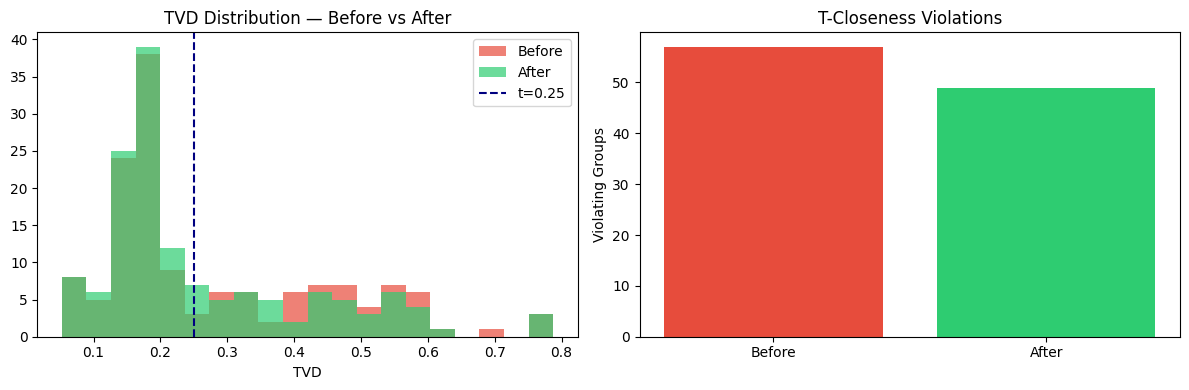

✅ Saved: ../results/t_closeness_analysis.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

tvd_before_vals = t_df['tvd'].tolist()

axes[0].hist(tvd_before_vals, bins=20, color='#e74c3c', alpha=0.7, label='Before')
axes[0].hist(tvd_after_vals,  bins=20, color='#2ecc71', alpha=0.7, label='After')
axes[0].axvline(x=t_threshold, color='navy', linestyle='--', label=f't={t_threshold}')
axes[0].set_title('TVD Distribution — Before vs After')
axes[0].set_xlabel('TVD')
axes[0].legend()

axes[1].bar(['Before', 'After'], [violations_before, violations_after], color=['#e74c3c', '#2ecc71'])
axes[1].set_title('T-Closeness Violations')
axes[1].set_ylabel('Violating Groups')

plt.tight_layout()
plt.savefig('../results/t_closeness_analysis.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Saved: ../results/t_closeness_analysis.png')

In [7]:
df_t.to_csv('../data/t_close_anonymized.csv', index=False)
print('✅ Saved: ../data/t_close_anonymized.csv')

t_metrics_out = {
    't_threshold': float(t_threshold),
    'metric': 'Total Variation Distance (categorical)',
    'sensitive_attribute': 'fitness_level',
    'violations': int(violations_after),
    'violation_rate': float(violations_after / len(tvd_after_vals)),
    'mean_tvd': float(np.mean(tvd_after_vals)),
    'corrections_made': corrections,
    'data_loss_percent': 0.0
}
with open('../results/t_closeness_metrics.json', 'w') as f:
    json.dump({'t_closeness_metrics': t_metrics_out}, f, indent=2)

print('\nSummary:')
for k, v in t_metrics_out.items():
    print(f'  {k}: {v}')

✅ Saved: ../data/t_close_anonymized.csv

Summary:
  t_threshold: 0.25
  metric: Total Variation Distance (categorical)
  sensitive_attribute: fitness_level
  violations: 49
  violation_rate: 0.34265734265734266
  mean_tvd: 0.2617022068668134
  corrections_made: 52
  data_loss_percent: 0.0
